<a href="https://colab.research.google.com/github/AdityaMalav1984/Data-Science-Group-3/blob/main/Grp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,
from sklearn.feature_selection import SelectKBest, f_classif

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ttest_ind

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")

Setup complete.


In [5]:
DATA_PATH = "/content/"

csv_files = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.csv')]

print(f"Found {len(csv_files)} CSV files")

Found 8 CSV files


In [6]:
df_list = []

for file in csv_files:
    try:
        temp_df = pd.read_csv(file, low_memory=False, encoding='latin1', on_bad_lines='skip')
        temp_df = temp_df.sample(frac=0.3, random_state=42)
        df_list.append(temp_df)
        print(f"Loaded: {file}")
    except:
        print(f"Skipped: {file}")

df = pd.concat(df_list, ignore_index=True)

print("Final shape:", df.shape)
df.head()

Loaded: /content/Friday-WorkingHours-Morning.pcap_ISCX.csv
Loaded: /content/Wednesday-workingHours.pcap_ISCX.csv
Loaded: /content/Monday-WorkingHours.pcap_ISCX.csv
Loaded: /content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loaded: /content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loaded: /content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loaded: /content/Tuesday-WorkingHours.pcap_ISCX.csv
Loaded: /content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Final shape: (849224, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,23908,2,2,70,184,35,35,35.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,80,105986,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53891,33560,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,185804,1,1,49,65,49,49,49.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,53,23768,1,1,52,114,52,52,52.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

print(df['Label'].value_counts())

Label
0     681467
4      69101
10     47603
2      38461
3       3047
7       2371
11      1791
6       1670
5       1644
1        560
12       459
14       202
9          8
13         7
8          4
Name: count, dtype: int64


In [8]:
df = df.sample(n=80000, random_state=42)
print("Reduced shape:", df.shape)

Reduced shape: (80000, 79)


In [9]:
class_counts = df['Label'].value_counts()
valid_classes = class_counts[class_counts > 10].index

df = df[df['Label'].isin(valid_classes)]
print("Classes:", len(valid_classes))

Classes: 12


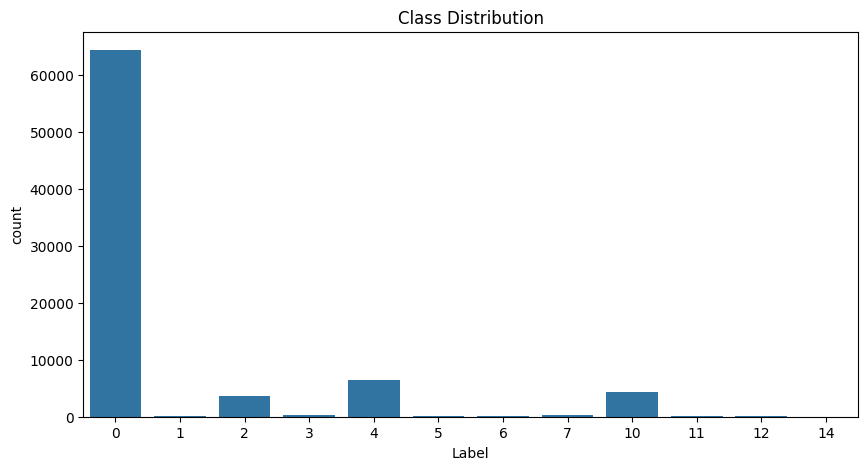

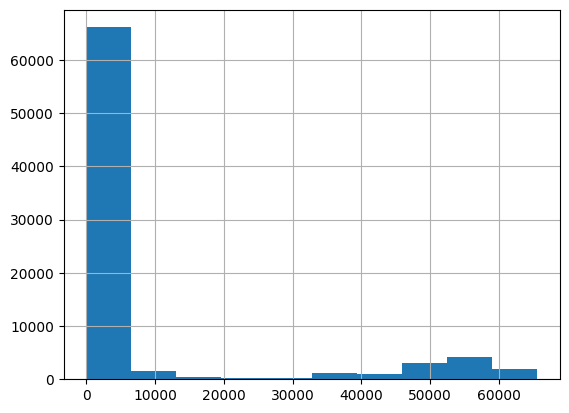

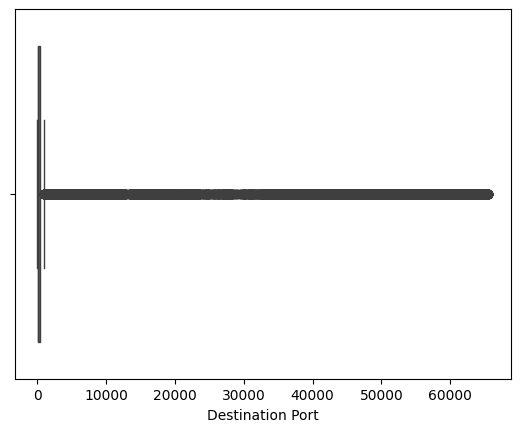

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Label'])
plt.title("Class Distribution")
plt.show()

df.iloc[:,0].hist()
plt.show()

sns.boxplot(x=df.iloc[:,0])
plt.show()

In [11]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df = df.drop(columns=to_drop)

X = df.drop('Label', axis=1)
y = df['Label']

In [12]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

print("PCA shape:", X_pca.shape)

PCA shape: (79997, 10)


In [13]:
from numpy.linalg import svd

U, S, Vt = svd(X.iloc[:1000], full_matrices=False)

print(U.shape, S.shape, Vt.shape)

(1000, 45) (45,) (45, 45)


In [14]:
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)

print("Selected features:", X_new.shape)

Selected features: (79997, 20)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_test = X_test[X_train.columns]

print(X_train.shape, X_test.shape)

(63997, 45) (16000, 45)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=15, class_weight='balanced', n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Linear SVM": LinearSVC(class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Naive Bayes": GaussianNB()
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print("All models trained.")

Training Random Forest...
Training Logistic Regression...
Training Linear SVM...
Training KNN...
Training Decision Tree...
Training Naive Bayes...
All models trained.



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12866
           1       0.30      0.30      0.30        10
           2       1.00      1.00      1.00       726
           3       1.00      0.95      0.97        61
           4       0.98      1.00      0.99      1299
           5       1.00      1.00      1.00        32
           6       1.00      0.94      0.97        31
           7       1.00      0.98      0.99        49
          10       1.00      1.00      1.00       882
          11       1.00      1.00      1.00        31
          12       0.75      0.67      0.71         9
          14       0.00      0.00      0.00         4

    accuracy                           1.00     16000
   macro avg       0.84      0.82      0.83     16000
weighted avg       1.00      1.00      1.00     16000



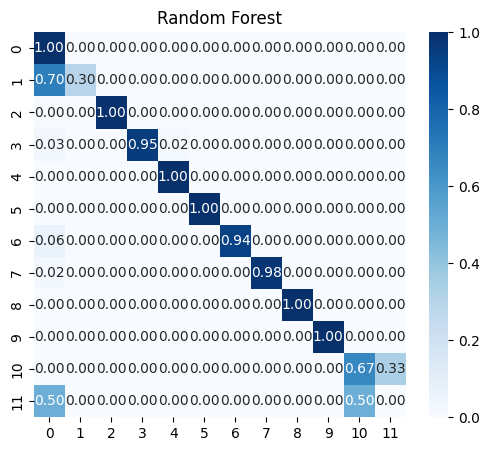


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     12866
           1       0.01      1.00      0.02        10
           2       0.71      1.00      0.83       726
           3       0.48      0.95      0.64        61
           4       0.85      0.99      0.91      1299
           5       0.43      1.00      0.60        32
           6       0.43      0.90      0.58        31
           7       0.25      0.98      0.40        49
          10       0.78      0.99      0.87       882
          11       0.09      1.00      0.17        31
          12       0.00      0.00      0.00         9
          14       0.02      1.00      0.04         4

    accuracy                           0.83     16000
   macro avg       0.42      0.88      0.50     16000
weighted avg       0.95      0.83      0.88     16000



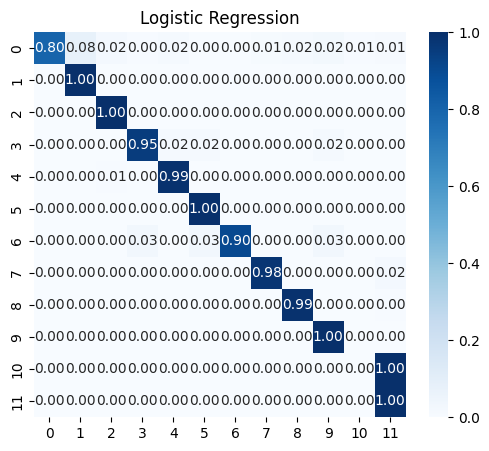


Linear SVM
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     12866
           1       0.02      0.30      0.04        10
           2       0.76      1.00      0.86       726
           3       0.48      0.93      0.64        61
           4       0.89      0.97      0.93      1299
           5       0.75      0.94      0.83        32
           6       0.67      0.65      0.66        31
           7       0.55      0.98      0.70        49
          10       0.84      0.99      0.91       882
          11       0.20      1.00      0.34        31
          12       0.00      0.00      0.00         9
          14       0.03      1.00      0.07         4

    accuracy                           0.93     16000
   macro avg       0.51      0.81      0.58     16000
weighted avg       0.96      0.93      0.94     16000



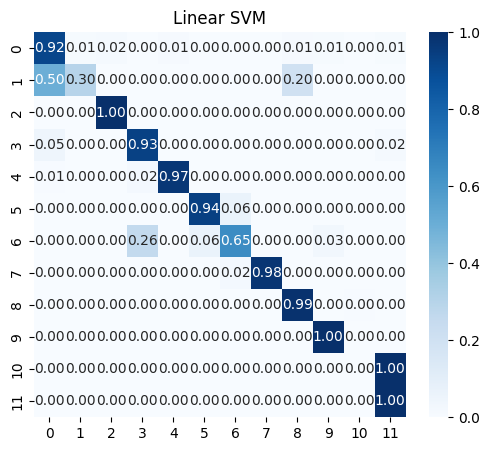


KNN
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     12866
           1       0.40      0.40      0.40        10
           2       0.99      0.99      0.99       726
           3       0.95      0.92      0.93        61
           4       0.99      0.99      0.99      1299
           5       0.97      0.97      0.97        32
           6       0.84      0.87      0.86        31
           7       1.00      0.98      0.99        49
          10       0.91      0.91      0.91       882
          11       0.97      1.00      0.98        31
          12       0.80      0.44      0.57         9
          14       0.00      0.00      0.00         4

    accuracy                           0.99     16000
   macro avg       0.82      0.79      0.80     16000
weighted avg       0.99      0.99      0.99     16000



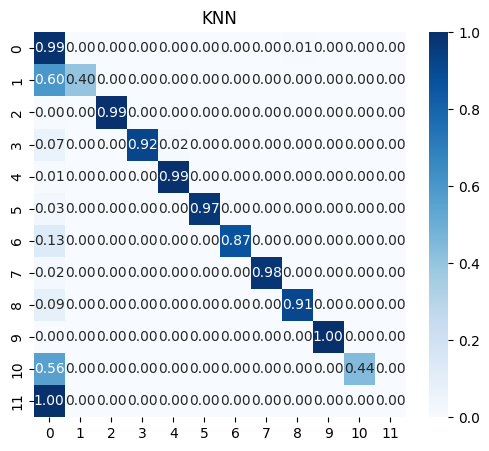


Decision Tree
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     12866
           1       0.00      0.00      0.00        10
           2       1.00      0.95      0.98       726
           3       0.94      0.84      0.89        61
           4       0.99      0.99      0.99      1299
           5       0.96      0.84      0.90        32
           6       0.96      0.87      0.92        31
           7       1.00      1.00      1.00        49
          10       1.00      1.00      1.00       882
          11       1.00      1.00      1.00        31
          12       0.00      0.00      0.00         9
          14       0.00      0.00      0.00         4

    accuracy                           0.99     16000
   macro avg       0.74      0.71      0.72     16000
weighted avg       0.99      0.99      0.99     16000



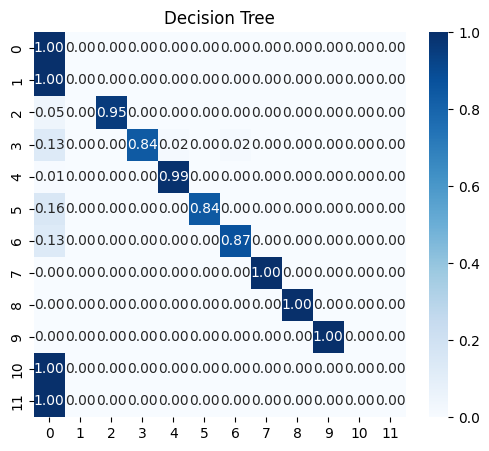


Naive Bayes
              precision    recall  f1-score   support

           0       1.00      0.71      0.83     12866
           1       0.00      1.00      0.01        10
           2       0.91      0.98      0.94       726
           3       0.11      0.97      0.20        61
           4       0.80      0.42      0.55      1299
           5       0.03      0.22      0.05        32
           6       0.07      0.87      0.13        31
           7       0.98      0.98      0.98        49
          10       0.85      0.98      0.91       882
          11       0.48      1.00      0.65        31
          12       0.00      0.00      0.00         9
          14       0.04      1.00      0.09         4

    accuracy                           0.71     16000
   macro avg       0.44      0.76      0.44     16000
weighted avg       0.96      0.71      0.81     16000



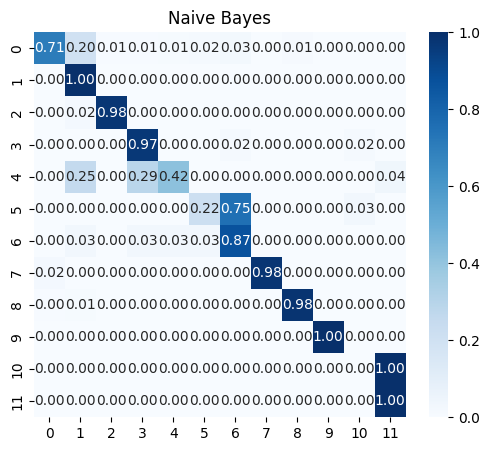

In [18]:
for name, model in trained_models.items():
    print(f"\n{name}")

    y_pred = model.predict(X_test_scaled)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.title(name)
    plt.show()

In [19]:
rf = trained_models["Random Forest"]

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_prob = rf.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

print("ROC AUC:", roc_auc)

ROC AUC: 0.999739930179544


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

rf = trained_models["Random Forest"]

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Probabilities
y_prob = rf.predict_proba(X_test_scaled)

# Plot ROC for each class
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (Random Forest)")
plt.legend()
plt.grid()

plt.show()

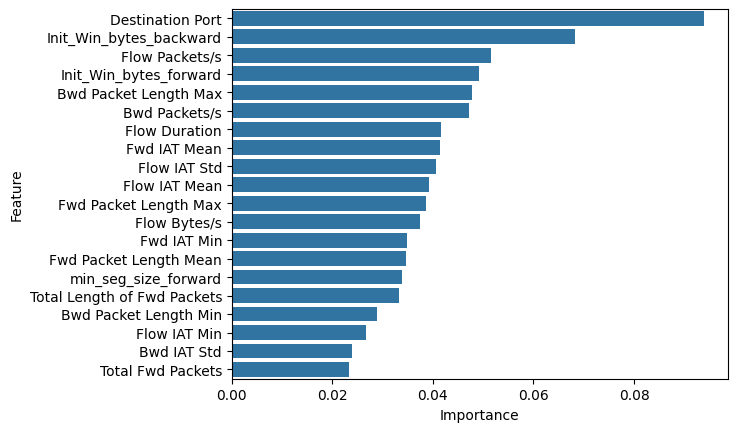

In [20]:
rf = trained_models["Random Forest"]

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False).head(20)

sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.show()

In [21]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

print("KMeans done")

KMeans done


In [3]:
joblib.dump(rf, "ids_model.pkl")

print("Model saved.")

NameError: name 'joblib' is not defined